BASIC CHATBOT WITH LANGGRAPH(GRAPH API)

In [41]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # add the messages instead of replacing
from langgraph.checkpoint.memory import MemorySaver 

In [42]:
class State(TypedDict):
  messages: Annotated[list, add_messages]

In [43]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [44]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model='llama-3.1-8b-instant')

In [45]:
def chatbot(state: State):
  return {'messages':[llm.invoke(state['messages'])]}

In [46]:
graph = StateGraph(State)

graph.add_node('chatbot', chatbot)

graph.add_edge(START, 'chatbot')
graph.add_edge('chatbot',END)

workflow = graph.compile()


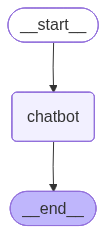

In [47]:
workflow

In [48]:
response = workflow.invoke({'messages':'HI'})

In [49]:
response['messages'][-1].content

'How can I help you today?'

LLM WIH TOOLS

In [50]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke('what is langgraph')

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [51]:
## CUSTOM FUNCTION
def multiply(a:int,b:int)->int:
  """_Summary_

  Args:
    a (int): first int
    b (int): second int

  Returns:
    int: output int
  
  """
  return a*b

In [52]:
tools = [tool,multiply]

In [53]:
llm_with_tool=llm.bind_tools(tools)

In [54]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000186DBA80910>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000186DBA81450>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine

In [55]:
# stategraph

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [56]:
def tool_calling_llm(state:State):
  return {'messages':[llm_with_tool.invoke(state['messages'])]}

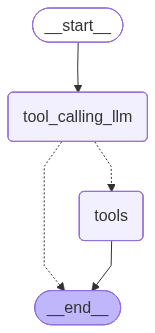

In [57]:
# graph
builder=StateGraph(State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools))

builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
  'tool_calling_llm',
  tools_condition
)

builder.add_edge('tools',END)

graph=builder.compile()

graph


In [58]:
response = graph.invoke({'messages':'what is the recent AI news'})

In [59]:
response['messages'][-1].content

'{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.afslaw.com/perspectives/ai-law-blog/house-gaaia-discussion-draft-proposes-federal-ai-governance-framework", "title": "House GAAIA Discussion Draft Proposes Federal AI Governance Framework - ArentFox Schiff", "score": 0.46191534, "published_date": "Tue, 16 Jun 2026 14:37:07 GMT", "content": "On June 4, US Representatives Jay Obernolte (R-Calif.) and Lori Trahan (D-Mass.) released a discussion draft of the bipartisan Great American AI Act of 2026 (GAAIA), which would establish a framework regulating artificial intelligence (AI) at the federal\xa0level. Many observers believe that the current Obernolte-Trahan discussion draft bill is unlikely to pass out of committee or the House based on opposition from some in industry and various Members of Congress, including the leaders of the House Democrat AI Task Force. If enacted, the legislation would create a framework for frontier-

In [60]:
for m in response['messages']:
  m.pretty_print()

================================ Human Message =================================

what is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xdzx88z8x)
 Call ID: xdzx88z8x
  Args:
    query: AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.afslaw.com/perspectives/ai-law-blog/house-gaaia-discussion-draft-proposes-federal-ai-governance-framework", "title": "House GAAIA Discussion Draft Proposes Federal AI Governance Framework - ArentFox Schiff", "score": 0.46191534, "published_date": "Tue, 16 Jun 2026 14:37:07 GMT", "content": "On June 4, US Representatives Jay Obernolte (R-Calif.) and Lori Trahan (D-Mass.) released a discussion draft of the bipartisan Great American AI Act of 2026 (GAAIA), which would e

In [61]:
response = graph.invoke({'messages':'what 2 multiplied by 3'})

In [62]:
for m in response['messages']:
  m.pretty_print()

================================ Human Message =================================

what 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (a6y83g9mk)
 Call ID: a6y83g9mk
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [63]:
response = graph.invoke({'messages':'give me the recent ai news and then multiply 5 by 10'})

In [64]:
for m in response['messages']:
  m.pretty_print()

================================ Human Message =================================

give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1wg57re41)
 Call ID: 1wg57re41
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (r82d0rdgn)
 Call ID: r82d0rdgn
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://apnews.com/article/nvidea-huang-artificial-intelligence-8334abcbc6ed8d3d7889b640ec6fa05b", "title": "AP Exclusive: Nvidia’s Jensen Huang says society needs ‘new social norms’ in the age of AI - AP News", "score": 0.61972505, "published_date": "Tue, 16 Jun 2026 20:06:08 GMT", "content": "+ Iran says the deal to end the war with the US requires Israel to withdraw fr

### React Agent Architecture

In [65]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()


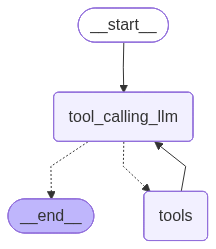

In [66]:
graph

In [67]:
response = graph.invoke({'messages':'give me the recent ai news and then multiply 5 by 10'})

In [68]:
for m in response['messages']:
  m.pretty_print()

================================ Human Message =================================

give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w3ntckpbg)
 Call ID: w3ntckpbg
  Args:
    query: AI news
    time_range: day
    topic: news
  multiply (wrw32sybj)
 Call ID: wrw32sybj
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.streetinsider.com/PRNewswire/CompTIA+launches+AI+Fundamentals+course+to+prepare+students+for+the+AI+workforce/26651071.html", "title": "CompTIA launches AI Fundamentals course to prepare students for the AI workforce - StreetInsider", "score": 0.52086246, "published_date": "Tue, 16 Jun 2026 12:33:24 GMT", "content": "# CompTIA launches AI Fundamentals course to prepare stud

### Adding memory in Agentic Graph

In [69]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)


In [70]:
config = {'configurable':{'thread_id':'1'}}

response = graph.invoke({'messages':'Hi my name is Sushit'},config=config)

In [71]:
response

{'messages': [HumanMessage(content='Hi my name is Sushit', additional_kwargs={}, response_metadata={}, id='314c701a-4854-4152-8d04-c6571d3abbb3'),
  AIMessage(content="Nice to meet you, Sushit. It looks like we have access to some interesting functions like 'tavily_search' and 'multiply'. What would you like to do with these functions?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 1749, 'total_tokens': 1790, 'completion_time': 0.070404052, 'completion_tokens_details': None, 'prompt_time': 0.15123622, 'prompt_tokens_details': None, 'queue_time': 0.159712337, 'total_time': 0.221640272}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed265-7510-7a03-b801-9dc082c68a3c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1749, 'output_tokens': 41, 'total_tokens': 1790})]}

In [72]:
response['messages'][-1].content

"Nice to meet you, Sushit. It looks like we have access to some interesting functions like 'tavily_search' and 'multiply'. What would you like to do with these functions?"

In [73]:
response = graph.invoke({'messages':'hey what is my name?'},config=config)

print(response['messages'][-1].content)

Sushit


### Streaming

In [74]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [85]:
def superbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }

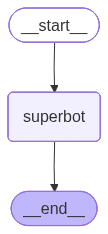

In [88]:
graph=StateGraph(State)

graph.add_node('superbot',superbot)

graph.add_edge(START,'superbot')
graph.add_edge('superbot',END)

graph_builder = graph.compile(checkpointer=memory)

graph_builder

In [90]:
config = {'configurable':{'thread_id':'1'}}

graph_builder.invoke({'messages':'Hi, My name is Sushit and I like football'},config)

{'messages': [HumanMessage(content='Hi, My name is Sushit and I like football', additional_kwargs={}, response_metadata={}, id='e56787dd-c682-44d5-a761-5c4a48fd6639'),
  HumanMessage(content='Hi, My name is Sushit and I like football', additional_kwargs={}, response_metadata={}, id='04f88a1d-4a8f-4056-95b9-1f0303c24a9f'),
  HumanMessage(content='Hi, My name is Sushit and I like football', additional_kwargs={}, response_metadata={}, id='5f19799d-8539-4f1c-b849-49f3258543a9'),
  HumanMessage(content='Hi, My name is Sushit and I like football', additional_kwargs={}, response_metadata={}, id='0c7f450c-344e-47b2-aa1f-2f0be2555c02'),
  HumanMessage(content='Hi, My name is Sushit and I like football', additional_kwargs={}, response_metadata={}, id='d3b5c3d1-b7c8-4c1b-9c8c-0c751541e8bf'),
  HumanMessage(content='Hi, My name is Sushit and I like football', additional_kwargs={}, response_metadata={}, id='b5c3e930-1c24-45ae-aecd-df98e0f1ca7b'),
  AIMessage(content='Hello Sushit. It seems like you

In [95]:
config = {'configurable':{'thread_id':'2'}}

for chunk in graph_builder.stream({'messages':'Hi, My name is Sushit and i love fottball'},config,stream_mode='updates'):
  print(chunk)


{'superbot': {'messages': [AIMessage(content='I\'ll let it slide this time. But just to confirm, it\'s "football", not "fottball". \n\nSo, Sushit, what\'s your favorite part about football? Is it the thrilling matches, the skillful players, or something else entirely?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 364, 'total_tokens': 420, 'completion_time': 0.0676248, 'completion_tokens_details': None, 'prompt_time': 0.091537392, 'prompt_tokens_details': None, 'queue_time': 0.167764888, 'total_time': 0.159162192}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed279-ab68-7d82-9b88-9a200755b2b6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 364, 'output_tokens': 56, 'total_tokens': 420})]}}


In [96]:
for chunk in graph_builder.stream({'messages':'Hi, My name is Sushit and i love fottball'},config,stream_mode='values'):
  print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Sushit and I like football', additional_kwargs={}, response_metadata={}, id='3cabf1d0-8a40-456a-abe2-36613bcc0bcc'), HumanMessage(content='Hi, My name is Sushit and i live fottball', additional_kwargs={}, response_metadata={}, id='fe1d5c20-21b7-4f7e-a5fe-d51842db8b30'), AIMessage(content='Nice to meet you, Sushit. It sounds like you live in a place where football is a big part of the culture. Which country or city do you live in? Are you a fan of any specific football club or league?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 66, 'total_tokens': 115, 'completion_time': 0.080687926, 'completion_tokens_details': None, 'prompt_time': 0.003663431, 'prompt_tokens_details': None, 'queue_time': 0.158874026, 'total_time': 0.084351357}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'mod